# Lesson 5: Random Forest

From unstable trees to robust ensembles.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## 1. Single Tree vs. Random Forest

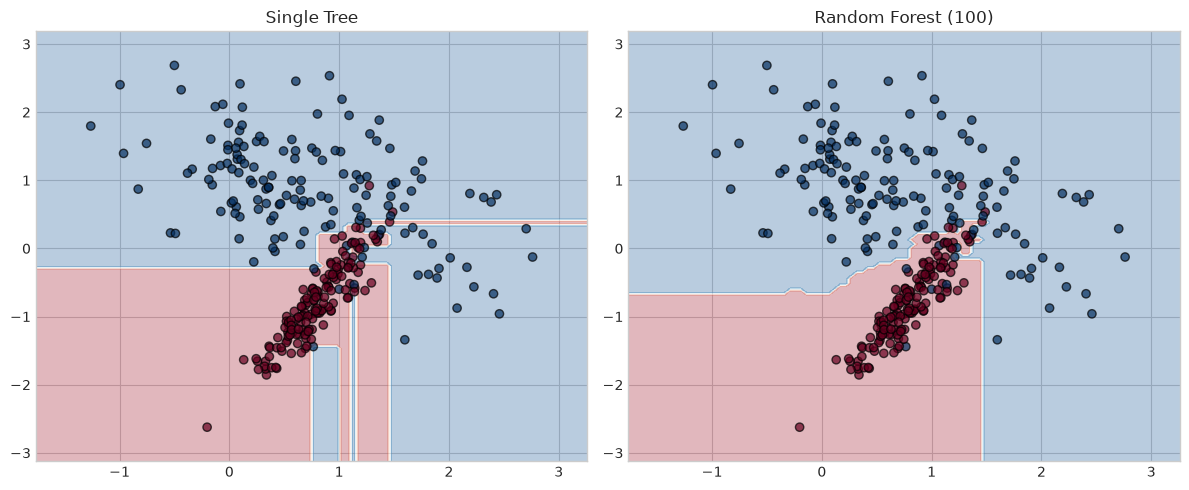

In [2]:
X, y = make_classification(n_samples=300, n_features=2, n_redundant=0,
                            n_clusters_per_class=1, class_sep=0.8, random_state=42)

tree = DecisionTreeClassifier(random_state=42)
forest = RandomForestClassifier(n_estimators=100, random_state=42)

xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 100),
                     np.linspace(X[:,1].min()-0.5, X[:,1].max()+0.5, 100))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, title in zip(axes, [tree, forest], ['Single Tree', 'Random Forest (100)']):
    model.fit(X, y)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k', alpha=0.7)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 2. Breast Cancer: Tree vs. Forest

In [3]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    'Tree (depth=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Tree (full)': DecisionTreeClassifier(random_state=42),
    'RF (100, depth=5)': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'RF (100, full)': RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    results.append({'Model': name, 'Train': train_acc, 'Test': test_acc})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model    Train     Test
   Tree (depth=5) 0.995604 0.947368
      Tree (full) 1.000000 0.947368
RF (100, depth=5) 0.993407 0.964912
   RF (100, full) 1.000000 0.964912


## 3. Effect of n_estimators

/home/mniev/.local/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/mniev/.local/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/home/mniev/.local/lib/python3.14/site-packages/sklearn/ensemble/_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


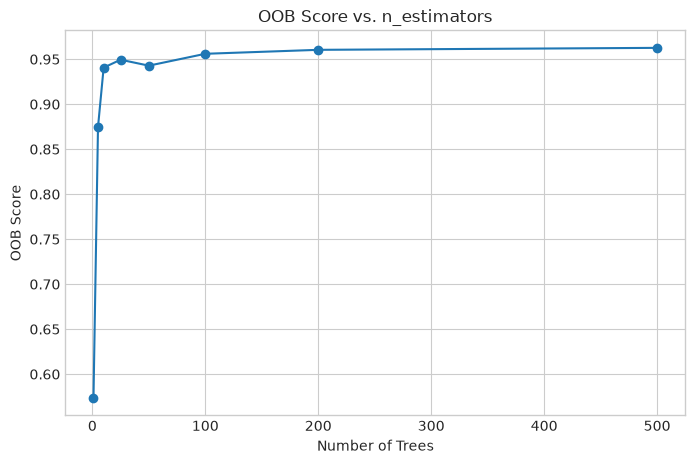

OOB at 100 trees: 0.956
OOB at 500 trees: 0.963


In [4]:
n_ests = [1, 5, 10, 25, 50, 100, 200, 500]
oob_scores = []

for n in n_ests:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)
    rf.fit(X_train, y_train)
    oob_scores.append(rf.oob_score_)

plt.figure(figsize=(8, 5))
plt.plot(n_ests, oob_scores, 'o-')
plt.xlabel('Number of Trees')
plt.ylabel('OOB Score')
plt.title('OOB Score vs. n_estimators')
plt.grid(True)
plt.show()

print(f"OOB at 100 trees: {oob_scores[5]:.3f}")
print(f"OOB at 500 trees: {oob_scores[-1]:.3f}")

## 4. Feature Importance

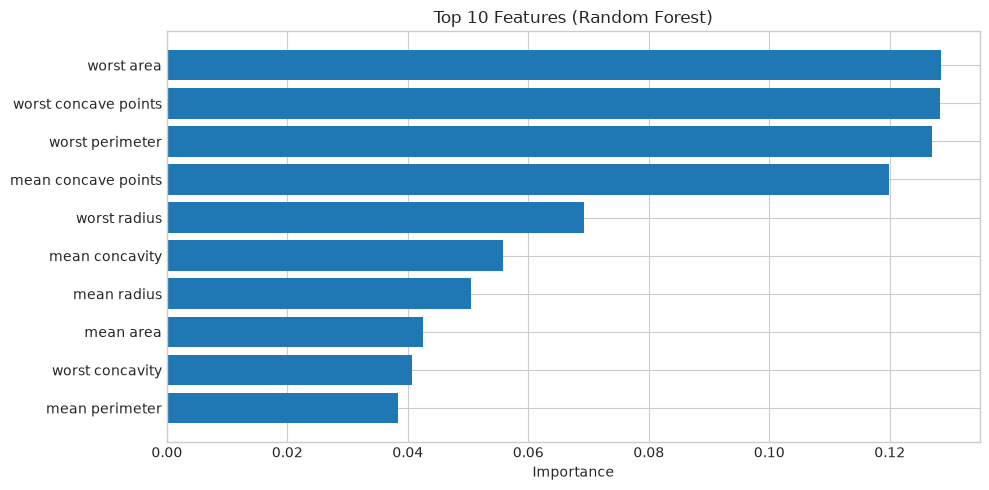

             feature  importance
          worst area    0.128549
worst concave points    0.128343
     worst perimeter    0.127079
 mean concave points    0.119801
        worst radius    0.069273
      mean concavity    0.055773
         mean radius    0.050439
           mean area    0.042542
     worst concavity    0.040747
      mean perimeter    0.038349


In [5]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.barh(importance['feature'], importance['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print(importance.to_string(index=False))

## 5. Biotechnology: Gene Expression

In [6]:
n_s, n_g = 300, 1000
X_gene = np.random.randn(n_s, n_g)
y_gene = (X_gene[:, 0]*0.5 + X_gene[:, 50]*0.3 - X_gene[:, 200]*0.4 > 0).astype(int)

rf_gene = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_gene.fit(X_gene, y_gene)

gene_imp = pd.DataFrame({
    'gene': [f'GENE_{i}' for i in range(n_g)],
    'importance': rf_gene.feature_importances_
}).sort_values('importance', ascending=False).head(5)
print("Top 5 predictive genes:")
print(gene_imp.to_string(index=False))
print(f"\nTest accuracy: {rf_gene.score(X_gene, y_gene):.3f}")

Top 5 predictive genes:
    gene  importance
  GENE_0    0.055574
GENE_200    0.012136
 GENE_50    0.011971
GENE_648    0.004925
GENE_115    0.004878

Test accuracy: 1.000


## 6. SaaS: Fraud Detection

In [7]:
n = 2000
fraud = pd.DataFrame({
    'amount': np.random.exponential(100, n),
    'distance': np.random.exponential(50, n),
    'hour': np.random.randint(0, 24, n),
    'prev_txns': np.random.poisson(20, n),
    'new_device': np.random.binomial(1, 0.1, n),
})
p = (0.001*fraud['amount'] + 0.002*fraud['distance'] + 
     0.02*(fraud['hour'] < 6) + 0.1*fraud['new_device'] + np.random.normal(0, 0.05, n))
fraud['is_fraud'] = (p > 0.15).astype(int)

rf_fraud = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_fraud.fit(fraud.drop('is_fraud', axis=1), fraud['is_fraud'])
y_pred = rf_fraud.predict(fraud.drop('is_fraud', axis=1))
print(f"Recall: {recall_score(fraud['is_fraud'], y_pred):.3f}")
print(f"Precision: {precision_score(fraud['is_fraud'], y_pred):.3f}")

Recall: 0.998
Precision: 1.000


## 7. Exercises

### Level 1
Why does bagging reduce variance?

### Level 2
Plot OOB score vs n_estimators on breast cancer. At what n does it stabilize?

### Level 3
Your RF has 99.5% train accuracy and 88% test. The single tree has 94% train and 90% test. What's wrong?

In [8]:
# Level 2 code

## 8. Coding Challenge

Write `tune_random_forest(X_train, y_train, X_val, y_val)` doing grid search over n_estimators and max_depth.

In [9]:
def tune_random_forest(X_train, y_train, X_val, y_val):
    best_model, best_acc = None, 0
    for n in [50, 100, 200]:
        for d in [3, 5, 10, None]:
            rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42)
            rf.fit(X_train, y_train)
            acc = accuracy_score(y_val, rf.predict(X_val))
            print(f"n={n}, depth={d}: val acc={acc:.3f}")
            if acc > best_acc:
                best_acc, best_model = acc, rf
    print(f"Best: {best_acc:.3f}")
    return best_model

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)
best_rf = tune_random_forest(X_tr, y_tr, X_val, y_val)

n=50, depth=3: val acc=0.947


n=50, depth=5: val acc=0.956
n=50, depth=10: val acc=0.930


n=50, depth=None: val acc=0.930


n=100, depth=3: val acc=0.947
n=100, depth=5: val acc=0.947


n=100, depth=10: val acc=0.947
n=100, depth=None: val acc=0.947


n=200, depth=3: val acc=0.947


n=200, depth=5: val acc=0.965


n=200, depth=10: val acc=0.965


n=200, depth=None: val acc=0.965
Best: 0.965


## Summary

- Random Forest = bagging + random feature subsets
- Averages many trees → reduces variance
- OOB score = free validation
- Feature importance identifies key predictors
- More robust than single trees
- Tune n_estimators and max_depth